## EDA 4: Análisis Exploratorio de los datos

* `Directorio:` ../data/store_zara_data
* `csv:`store_zara.csv

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
%matplotlib inline

In [54]:
df_store_zara = pd.read_csv('../data/store_zara_data/store_zara.csv', sep=',')
df_store_zara.head(2)

,brand,url,sku,name,description,price,currency,images,scraped_at,terms,section,error,image_downloads
0,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,['https://static.zara.net/photos///2023/I/0/2/...,2024-02-19T08:50:05.654618,jackets,MAN,NaN,"['e8e4ae57-8b72-44ff-aa5d-84de3ed37d9e', '0cb3..."
1,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,['https://static.zara.net/photos///2024/V/0/1/...,2024-02-19T08:50:06.590930,jackets,MAN,NaN,"['b42b0725-cfe2-4748-af3e-3abe590d83cd', 'ed9c..."


In [55]:
df_store_zara['terms'].unique()

array(['jackets', 'puffers', 'pants', 'jeans', 'sweaters', 'cardigans',
       'hoodies', 'sweatshirts', 't-shirts', 'overshirts', 'linen',
       'shorts', 'suits', 'blazers', 'tracksuits', 'coats', 'shoes',
       'bags', 'dresses', 'skirts', 'tops', 'bodysuits', 'knitwear'],
      dtype=object)

## Generación de dataset: Mujer / Hombre

In [56]:
# Paso 1: separar por hombre y mujer el conjunto datos
store_zara_man = df_store_zara[df_store_zara['section'] == 'MAN']
store_zara_woman = df_store_zara[df_store_zara['section'] == 'WOMAN']


## Filtrar el conjunto de datos: Calzado Mujer / Calzado Hombre

In [57]:
# Paso 2: filtrar registros con terms == 'shoes'
zara_man_shoes = store_zara_man[store_zara_man['terms'] == 'shoes']
zara_woman_shoes = store_zara_woman[store_zara_woman['terms'] == 'shoes']

In [58]:
print(zara_man_shoes['terms'].unique())
print(zara_woman_shoes['terms'].unique())

['shoes']
['shoes']


## Seleccion de columnas relevantes en cada conjunto de datos: zara_man_shoes /  zara_woman_shoes

In [59]:
# Paso 3: seleccionar las columnas relevantes
df_zara_man_shoes = zara_man_shoes[['name','description','price','currency','terms','image_downloads']].reset_index(drop=True)
df_zara_woman_shoes = zara_woman_shoes[['name','description','price','currency','terms','image_downloads']].reset_index(drop=True)

In [60]:
print(f'Hombre Calzado: {df_zara_man_shoes.shape}')
df_zara_man_shoes.head(3)

Hombre Calzado: (158, 6)


,name,description,price,currency,terms,image_downloads
0,CHUNKY SOLE CHELSEA BOOTS,Chelsea boots. Shaft with elastic goring on bo...,59.9,USD,shoes,"['8569e73f-b1be-476a-89b4-9afa3f6ff89b', 'd54a..."
1,CHUNKY SOLE SNEAKERS,Sneakers. Upper in a combination of materials ...,49.9,USD,shoes,"['38da5001-d5b0-462c-8372-f5381e17ea17', 'af82..."
2,SQUARED TOE LEATHER BOOTS,Leather ankle boots. Square shaped. Side zippe...,159.0,USD,shoes,"['999f3076-ca9c-4ca5-b23f-f6182ae29ca6', '435c..."


In [61]:
print(f'Mujer Calzado: {df_zara_woman_shoes.shape}')
df_zara_woman_shoes.head(3)

Mujer Calzado: (287, 6)


,name,description,price,currency,terms,image_downloads
0,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,shoes,"['79d241c5-2dcc-4fc2-8520-3611fe0be740', 'a462..."
1,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"['3c5a4b1d-407b-4683-8489-795e1177aa4a', '769a..."
2,HIGH HEEL SLINGBACK PUMPS,Heeled slingbacks with faux patent leather fin...,49.9,USD,shoes,"['8f6fa50a-6df1-4d4f-9af5-3dc5b59abc74', 'a497..."


## Hombre: df_zara_man_shoes

In [62]:
df_zara_man_shoes.head(3)

,name,description,price,currency,terms,image_downloads
0,CHUNKY SOLE CHELSEA BOOTS,Chelsea boots. Shaft with elastic goring on bo...,59.9,USD,shoes,"['8569e73f-b1be-476a-89b4-9afa3f6ff89b', 'd54a..."
1,CHUNKY SOLE SNEAKERS,Sneakers. Upper in a combination of materials ...,49.9,USD,shoes,"['38da5001-d5b0-462c-8372-f5381e17ea17', 'af82..."
2,SQUARED TOE LEATHER BOOTS,Leather ankle boots. Square shaped. Side zippe...,159.0,USD,shoes,"['999f3076-ca9c-4ca5-b23f-f6182ae29ca6', '435c..."


In [63]:
# Registros de zapatos con edicion limitada.
df_zara_man_shoes[df_zara_man_shoes['name'].str.contains(r'LIMITED EDITION', case=False)]

,name,description,price,currency,terms,image_downloads
12,CHUNKY LEATHER SHOES LIMITED EDITION,Derby style shoes. Made of leather. Lacing wit...,139.00,USD,shoes,"['7293560d-b0ca-45c0-a19a-73cd05c77481', 'b98b..."
32,HIGH SHAFT LEATHER BOOTS - LIMITED EDITION,Mid calf leather boots. Made of leather. Monoc...,259.00,USD,shoes,"['d973cdd0-bec8-4ad8-9f03-12db72efb356', '81a6..."
36,LEATHER PENNY LOAFERS - LIMITED EDITION,Loafers. Made of leather. Ornamental saddle de...,119.00,USD,shoes,"['ed7a36a3-91fa-418a-ae01-fae919c2f757', 'b98b..."
57,LEATHER PENNY LOAFERS - LIMITED EDITION,Loafers. Made of leather. Ornamental saddle de...,119.00,USD,shoes,"['646b21b6-dce9-488d-a98e-f41bd9de7558', '5888..."
63,LEATHER DERBY SHOES - LIMITED EDITION,Derby style shoes. Made of leather. Smooth upp...,119.00,USD,shoes,"['09cc41a5-0c1b-481d-a7d0-eda637098929', 'f806..."
67,HIGH SHAFT LACE-UP LEATHER BOOTS LIMITED EDITION,High shaft boots. Made of leather. Laces with ...,229.00,USD,shoes,"['8ea809b1-a960-434f-9719-7d4c3816648d', '282c..."
138,MULTIPIECE LACE-UP BOOTS - LIMITED EDITION,Laced boots with leather upper. Laces with nin...,19.99,USD,shoes,"['4b83f9ab-66ae-4160-86c8-6907fceaf01b', '4a81..."


In [64]:
print(df_zara_man_shoes.loc[12, 'name'])
print(df_zara_man_shoes.loc[12, 'description'])

CHUNKY LEATHER SHOES LIMITED EDITION
Derby style shoes. Made of leather. Lacing with four pairs of eyelets. Rounded shape with pronounced toe cap. Double welt around upper. Chunky lug soles.

Limited edition.


### Registros que no contienen tipo de calzado o contienen codigo erratas en la columna name

In [12]:
# Contiene un codigo 001 que impide seleccionar la catergia correcta
df_zara_man_shoes[df_zara_man_shoes['name'].str.contains(r'001', case=False)]

,name,description,price,currency,terms,image_downloads
11,ORIGINS SNEAKER 001,Running shoes. Made with leather and a combina...,119.0,USD,shoes,"['9fe38305-bad3-4be9-999b-c962b7e0bdb0', 'f373..."


In [13]:
# El Producto no esta catalogado como zapato pero es un cinturon
df_zara_man_shoes[df_zara_man_shoes['name'].str.contains(r'belt', case=False)]

,name,description,price,currency,terms,image_downloads
142,TOPSTITCH LEATHER BELT,Belt made of flexible and durable calfskin. Co...,2.99,USD,shoes,['67ca286d-10c9-4138-96aa-2e49ca8bf20e']


In [14]:
df_zara_man_shoes[df_zara_man_shoes['name'].str.contains(r'tops', case=False)]

,name,description,price,currency,terms,image_downloads
111,SUEDE HIGH-TOPS,High top sneakers. Upper in a combination of p...,59.90,USD,shoes,"['bd96324f-30b3-4474-98b8-0f253b6aae36', '328a..."
114,TOPSTITCH SNEAKERS,Sneakers. Pieces and topstitching at upper. La...,45.90,USD,shoes,"['a750fee2-1325-4edb-97bf-c4e4fcc85a46', '889d..."
142,TOPSTITCH LEATHER BELT,Belt made of flexible and durable calfskin. Co...,2.99,USD,shoes,['67ca286d-10c9-4138-96aa-2e49ca8bf20e']


In [15]:
# fila 111
cadena = df_zara_man_shoes.loc[111, 'image_downloads']
print(type(cadena))
print(cadena)
json_cadena = cadena.replace("'", "\"")
print(type(json_cadena))
print(json_cadena)
# Parsear el arreglo JSON
lista_imagenes = json.loads(json_cadena)

<class 'str'>
['bd96324f-30b3-4474-98b8-0f253b6aae36', '328a6b32-7ba0-4b19-a779-180b2401f5b7', 'a5b0c546-c3f9-4194-b98b-c4f1cfb7f054', 'bfdba209-6e4f-4ad8-ab59-346bf1d24b65', 'e26ef007-a457-4552-98ee-0463c3e68701', 'f91ad4b3-64b2-4aea-98cb-74d22c6a7aa5']
<class 'str'>
["bd96324f-30b3-4474-98b8-0f253b6aae36", "328a6b32-7ba0-4b19-a779-180b2401f5b7", "a5b0c546-c3f9-4194-b98b-c4f1cfb7f054", "bfdba209-6e4f-4ad8-ab59-346bf1d24b65", "e26ef007-a457-4552-98ee-0463c3e68701", "f91ad4b3-64b2-4aea-98cb-74d22c6a7aa5"]


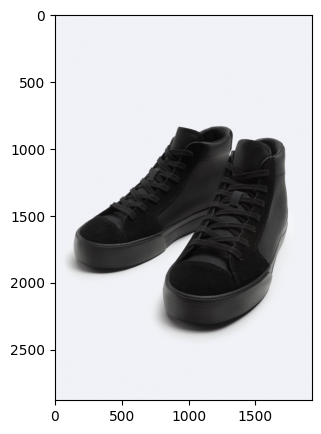

In [16]:
# fila 111

image_path = "../data/store_zara_data/images/zara/" + 'bfdba209-6e4f-4ad8-ab59-346bf1d24b65' + ".jpg"
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(16, 5))
plt.imshow(image)
plt.show()

In [17]:
cadena = df_zara_man_shoes.loc[114, 'image_downloads']
print(type(cadena))
print(cadena)
json_cadena = cadena.replace("'", "\"")
print(type(json_cadena))
print(json_cadena)
# Parsear el arreglo JSON
lista_imagenes = json.loads(json_cadena)

<class 'str'>
['a750fee2-1325-4edb-97bf-c4e4fcc85a46', '889d4e0e-362b-428a-b535-effb73cc7be6', 'b9ea46a4-29c8-49f7-9b61-8a0f2b5a225b', 'ca7c5890-5caf-4026-90a8-721dbb274449', '56702c77-88fa-4105-be68-7951fec2e30f', '14b360f9-24c7-4379-8974-add7db4010d5']
<class 'str'>
["a750fee2-1325-4edb-97bf-c4e4fcc85a46", "889d4e0e-362b-428a-b535-effb73cc7be6", "b9ea46a4-29c8-49f7-9b61-8a0f2b5a225b", "ca7c5890-5caf-4026-90a8-721dbb274449", "56702c77-88fa-4105-be68-7951fec2e30f", "14b360f9-24c7-4379-8974-add7db4010d5"]


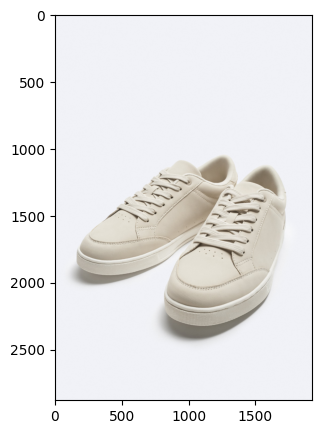

In [18]:
# fila 114

image_path = "../data/store_zara_data/images/zara/" + 'ca7c5890-5caf-4026-90a8-721dbb274449' + ".jpg"
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(16, 5))
plt.imshow(image)
plt.show()

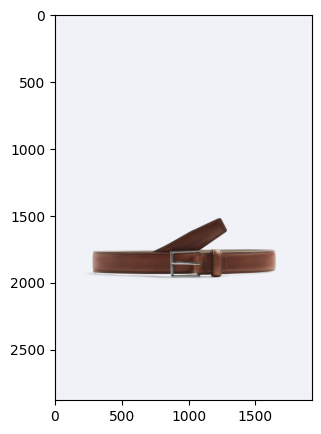

In [19]:
# Fila 142
image_path = "../data/store_zara_data/images/zara/" + '67ca286d-10c9-4138-96aa-2e49ca8bf20e' + ".jpg"
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(16, 5))
plt.imshow(image)
plt.show()

In [20]:
df_zara_man_shoes[df_zara_man_shoes['name'].str.contains(r'slides', case=False)]

,name,description,price,currency,terms,image_downloads
23,TEXTURED SLIDES,Solid color slide sandals. Rubber platform sol...,25.9,USD,shoes,"['8472812c-81b2-4b9c-a0fc-ccf1eb6aabc5', '0676..."
49,SUEDE SLIDES,Sandals. Made of leather with a suede finish. ...,59.9,USD,shoes,"['5a21d597-6fa4-447f-a6b7-f91dd0733b29', 'b89f..."
137,WOVEN LEATHER SLIDES,Sandals. Made of leather. Three woven wide str...,49.9,USD,shoes,"['fb2651f7-a0ee-474e-a6fd-7ee7c7b95b8a', '1c6f..."


# Filas que deben ser modificadas: 

* 11 : Quitar el codigo 001 y el espacio final.
* 111 : Añadir la palabra 'sneaker' al final de la cadena.
* 142 : Eliminar fila. El Producto esta catalogado como zapato pero es un cinturon.
* 23, 49, 137 : Reemplazar slides por sandals

In [21]:
# Convertir a minusculas la columna name
df_zara_man_shoes.loc[:,'name'] = df_zara_man_shoes['name'].str.lower()

In [22]:
# Reemplazar ' 001' por cadena vacia en la columna name
df_zara_man_shoes.loc[11, 'name'] = df_zara_man_shoes.loc[11, 'name'].replace(' 001', '').strip() + 's'

In [23]:
# Añadir la palabra 'sneakers' al final de la cadena.
df_zara_man_shoes.loc[111, 'name'] = df_zara_man_shoes.loc[111, 'name'] + ' sneakers'

In [24]:
# Eliminar la fila con índice 142
df_zara_man_shoes.drop(142, axis=0, inplace=True)

In [25]:
# Reemplazar guiones por espacios en la columna name
df_zara_man_shoes.loc[23, 'name'] = df_zara_man_shoes.loc[23, 'name'].replace('slides', 'sandals')
df_zara_man_shoes.loc[49, 'name'] = df_zara_man_shoes.loc[49, 'name'].replace('slides', 'sandals')
df_zara_man_shoes.loc[137, 'name'] = df_zara_man_shoes.loc[137, 'name'].replace('slides', 'sandals')

In [26]:
#Comprobaciones
print(df_zara_man_shoes.loc[11, 'name'])
print(df_zara_man_shoes.loc[111, 'name'])
print(df_zara_man_shoes.loc[23, 'name'])
print(df_zara_man_shoes.loc[49, 'name'])
print(df_zara_man_shoes.loc[137, 'name'])


origins sneakers
suede high-tops sneakers
textured sandals
suede sandals
woven leather sandals


In [27]:
# Reemplazar guiones por espacios en la columna name
df_zara_man_shoes.loc[:,'name']= df_zara_man_shoes['name'].str.replace(r'-', '', case=False, regex=True)

In [28]:

def get_limited_edition(x:str):
    """ Funcion para identificar si el producto es de edicion limitada"""
    
    if 'limited edition' in x:
        return 'limited edition'
    else:
        return ''
    
# Registros de zapatos con edicion limitada. 
df_zara_man_shoes['edition_type'] = df_zara_man_shoes['name'].apply(get_limited_edition)
# Reemplazar limited edition por cadena vacia en la columna name
df_zara_man_shoes.loc[:,'name']= df_zara_man_shoes['name'].str.replace(r'limited edition', '', case=False, regex=True)


In [29]:
# Eliminar espacios al principio y al final de la columna name
df_zara_man_shoes.loc[:,'name'] = df_zara_man_shoes['name'].apply(lambda x : x.strip())

df_zara_man_shoes.loc[12, :]

name                                            chunky leather shoes
description        Derby style shoes. Made of leather. Lacing wit...
price                                                          139.0
currency                                                         USD
terms                                                          shoes
image_downloads    ['7293560d-b0ca-45c0-a19a-73cd05c77481', 'b98b...
edition_type                                         limited edition
Name: 12, dtype: object

In [30]:
def get_type_od_shoes(x:str):
    words = x.split(' ')
    # Obtener el ultimo elemento de la lista
    return words[-1]

# Registros de zapatos con edicion limitada. 
df_zara_man_shoes['category'] = df_zara_man_shoes['name'].apply(get_type_od_shoes)

In [31]:
df_zara_man_shoes['category'].unique()

array(['boots', 'sneakers', 'loafers', 'shoes', 'sandals', 'clogs',
       'espadrilles'], dtype=object)

In [32]:
df_zara_man_shoes.isna().sum()

name               0
description        0
price              0
currency           0
terms              0
image_downloads    0
edition_type       0
category           0
dtype: int64

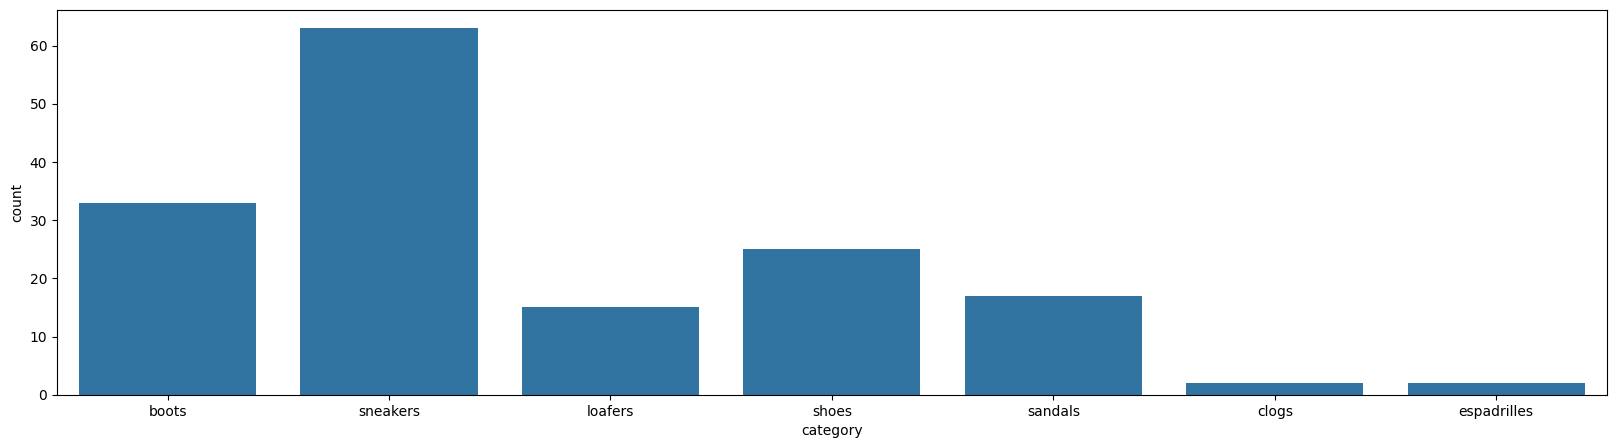

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,5))
ax = sns.countplot(data=df_zara_man_shoes, x='category',  ax=ax, legend=True)

In [34]:
df_zara_man_shoes.head(2)

,name,description,price,currency,terms,image_downloads,edition_type,category
0,chunky sole chelsea boots,Chelsea boots. Shaft with elastic goring on bo...,59.9,USD,shoes,"['8569e73f-b1be-476a-89b4-9afa3f6ff89b', 'd54a...",,boots
1,chunky sole sneakers,Sneakers. Upper in a combination of materials ...,49.9,USD,shoes,"['38da5001-d5b0-462c-8372-f5381e17ea17', 'af82...",,sneakers


### Reemplazar str (json) en el campo image:_downloads por  lista  de string con el codigo de cada imagen

In [35]:
def get_images_json_to_list(x:str):
    json_cadena = x.replace("'", "\"")
    lista_imagenes = json.loads(json_cadena)
    return lista_imagenes

# Convertir la columna image_downloads en una lista de strings
df_zara_man_shoes.loc[:,'image_downloads'] = df_zara_man_shoes['image_downloads'].apply(get_images_json_to_list)


### Contabilizar el número de imagenes por registro o fila

In [36]:
# Convertir la columna image_downloads en una lista de strings
df_zara_man_shoes.loc[:,'total_images'] = df_zara_man_shoes['image_downloads'].apply(len)

In [37]:
# Valores únicos de la columna 'total_images'. Se observa el número de imagenes por producto es de 4,6,7 u 8.
df_zara_man_shoes['total_images'].unique()

array([6, 4, 7, 8])

In [38]:
df_zara_man_shoes[df_zara_man_shoes['total_images']==8]

,name,description,price,currency,terms,image_downloads,edition_type,category,total_images
77,chunky sole monochrome sneakers,Sneakers. Upper in a combination of pieces and...,15.99,USD,shoes,"[83cc9d81-1c6e-44a4-99cb-423ecba9f85c, 30875f7...",,sneakers,8
80,embossed slip on sneakers,Slip on casual sneakers. Decorative embossed d...,39.90,USD,shoes,"[404e9b1e-d922-4fcb-9c33-0158f4e5a425, 4d20d10...",,sneakers,8
109,multicolor sneakers,Sneakers. Combination of colors and pieces at ...,69.90,USD,shoes,"[4dc2fee4-16b9-49d8-bb42-88ecc4ca6608, d52d293...",,sneakers,8
138,multipiece laceup boots,Laced boots with leather upper. Laces with nin...,19.99,USD,shoes,"[4b83f9ab-66ae-4160-86c8-6907fceaf01b, 4a814a8...",limited edition,boots,8


## Mostrar secuencia de imágenes en base el número de imágenes por producto detectado 4, 6, 7, 8 para ver si sigue un patron de visualización.

In [39]:
def show_images(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=1, ncols=len(lista_imagenes), figsize=(20,5))
    for i, image in enumerate(lista_imagenes):
        image_path = "../data/store_zara_data/images/zara/" + str(image) + ".jpg"
        image = Image.open(image_path).convert("RGB")
        axs[i].imshow(image)
        axs[i].axis('off')
    plt.tight_layout() #  ajustar automáticamente el tamaño del gráfico y los márgenes para que se ajuste correctamente a la ventana.
    plt.show()

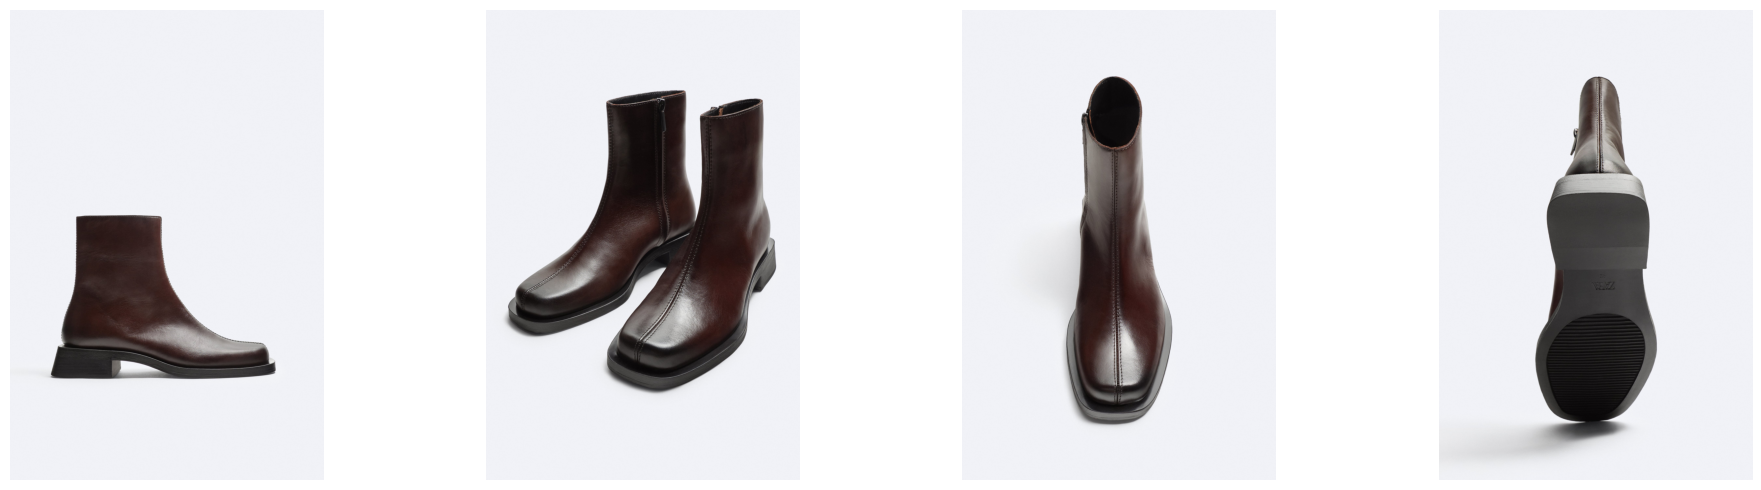

In [40]:
imagenes_len_4 = df_zara_man_shoes.loc[2, 'image_downloads']
show_images(imagenes_len_4)

In [ ]:
imagenes_len_6 = df_zara_man_shoes.loc[3, 'image_downloads']
show_images(imagenes_len_6)

In [ ]:
imagenes_len_7 = df_zara_man_shoes.loc[4, 'image_downloads']
show_images(imagenes_len_7)

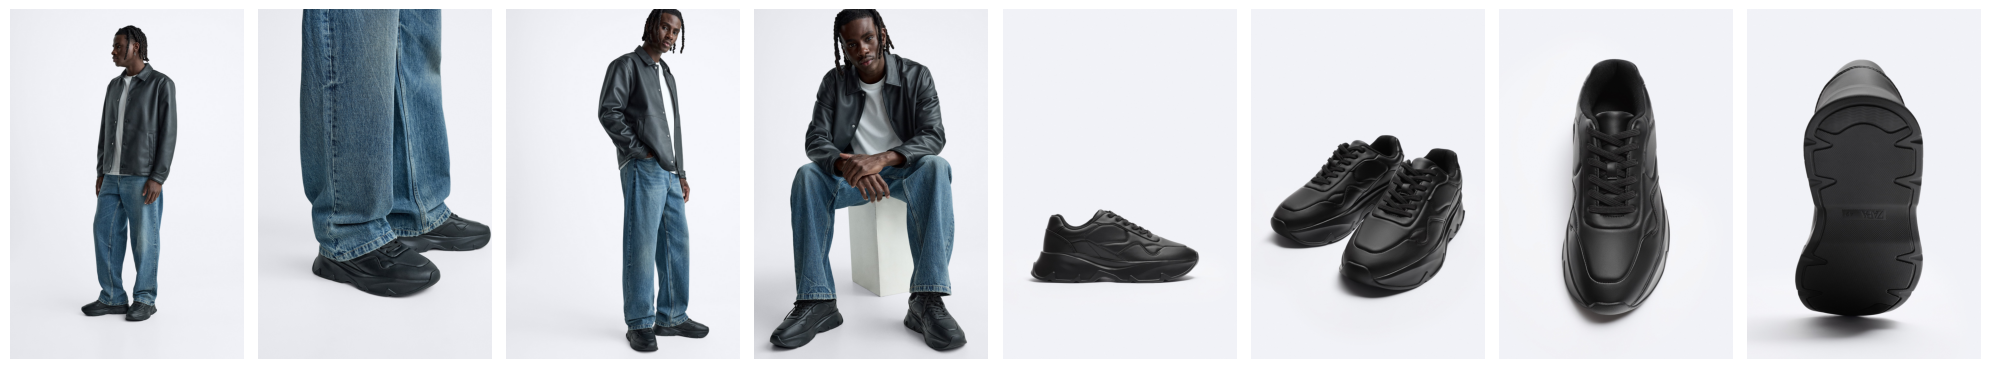

In [43]:
imagenes_len_8 = df_zara_man_shoes.loc[77, 'image_downloads']
show_images(imagenes_len_8)

## El producto de la fila 11, es el único registro en productos de calzado que no sigue la secuencia o patron de imagen.


In [ ]:
imagenes_len_4_11 = df_zara_man_shoes.loc[11, 'image_downloads']
show_images(imagenes_len_4_11)

In [45]:
print(imagenes_len_4_11[2])
print(imagenes_len_4_11[-4])

1d5814c1-bd21-4cf2-8f61-cd3672f2df03
1d5814c1-bd21-4cf2-8f61-cd3672f2df03


## Selección de vista isométrica como única imagen de producto.
Observamos que la posicion -3 es una vista isometrica de cada producto de calzado.

In [46]:
# df_zara_man_shoes['iso_image'] = df_zara_man_shoes.loc[11, 'image_downloads'].apply([-4])

In [47]:
# df_zara_man_shoes['iso_image'] = df_zara_man_shoes['image_downloads'].apply([-3])

In [48]:
# df_zara_man_shoes['iso_image'] = df_zara_man_shoes['image_downloads'].apply(lambda x: x[2] if x.index == 11 else x[-3])

In [49]:
df_zara_man_shoes['iso_image'] = ''

for index, row in df_zara_man_shoes.iterrows():
     if index == 11: 
        df_zara_man_shoes.loc[index, 'iso_image'] = row['image_downloads'][2]
     else:
        df_zara_man_shoes.loc[index, 'iso_image'] = row['image_downloads'][-3]

In [50]:
def show_images12x13(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=12, ncols=13, figsize=(20,15))
    for i in range(12):
        for j in range(13):
            if i * 13 + j < len(lista_imagenes):
                image_path = "../data/store_zara_data/images/zara/" + str(lista_imagenes[i * 13 + j]) + ".jpg"
                image = Image.open(image_path).convert("RGB")
                axs[i, j].imshow(image)
                axs[i, j].axis('off')
    plt.tight_layout()
    plt.show()

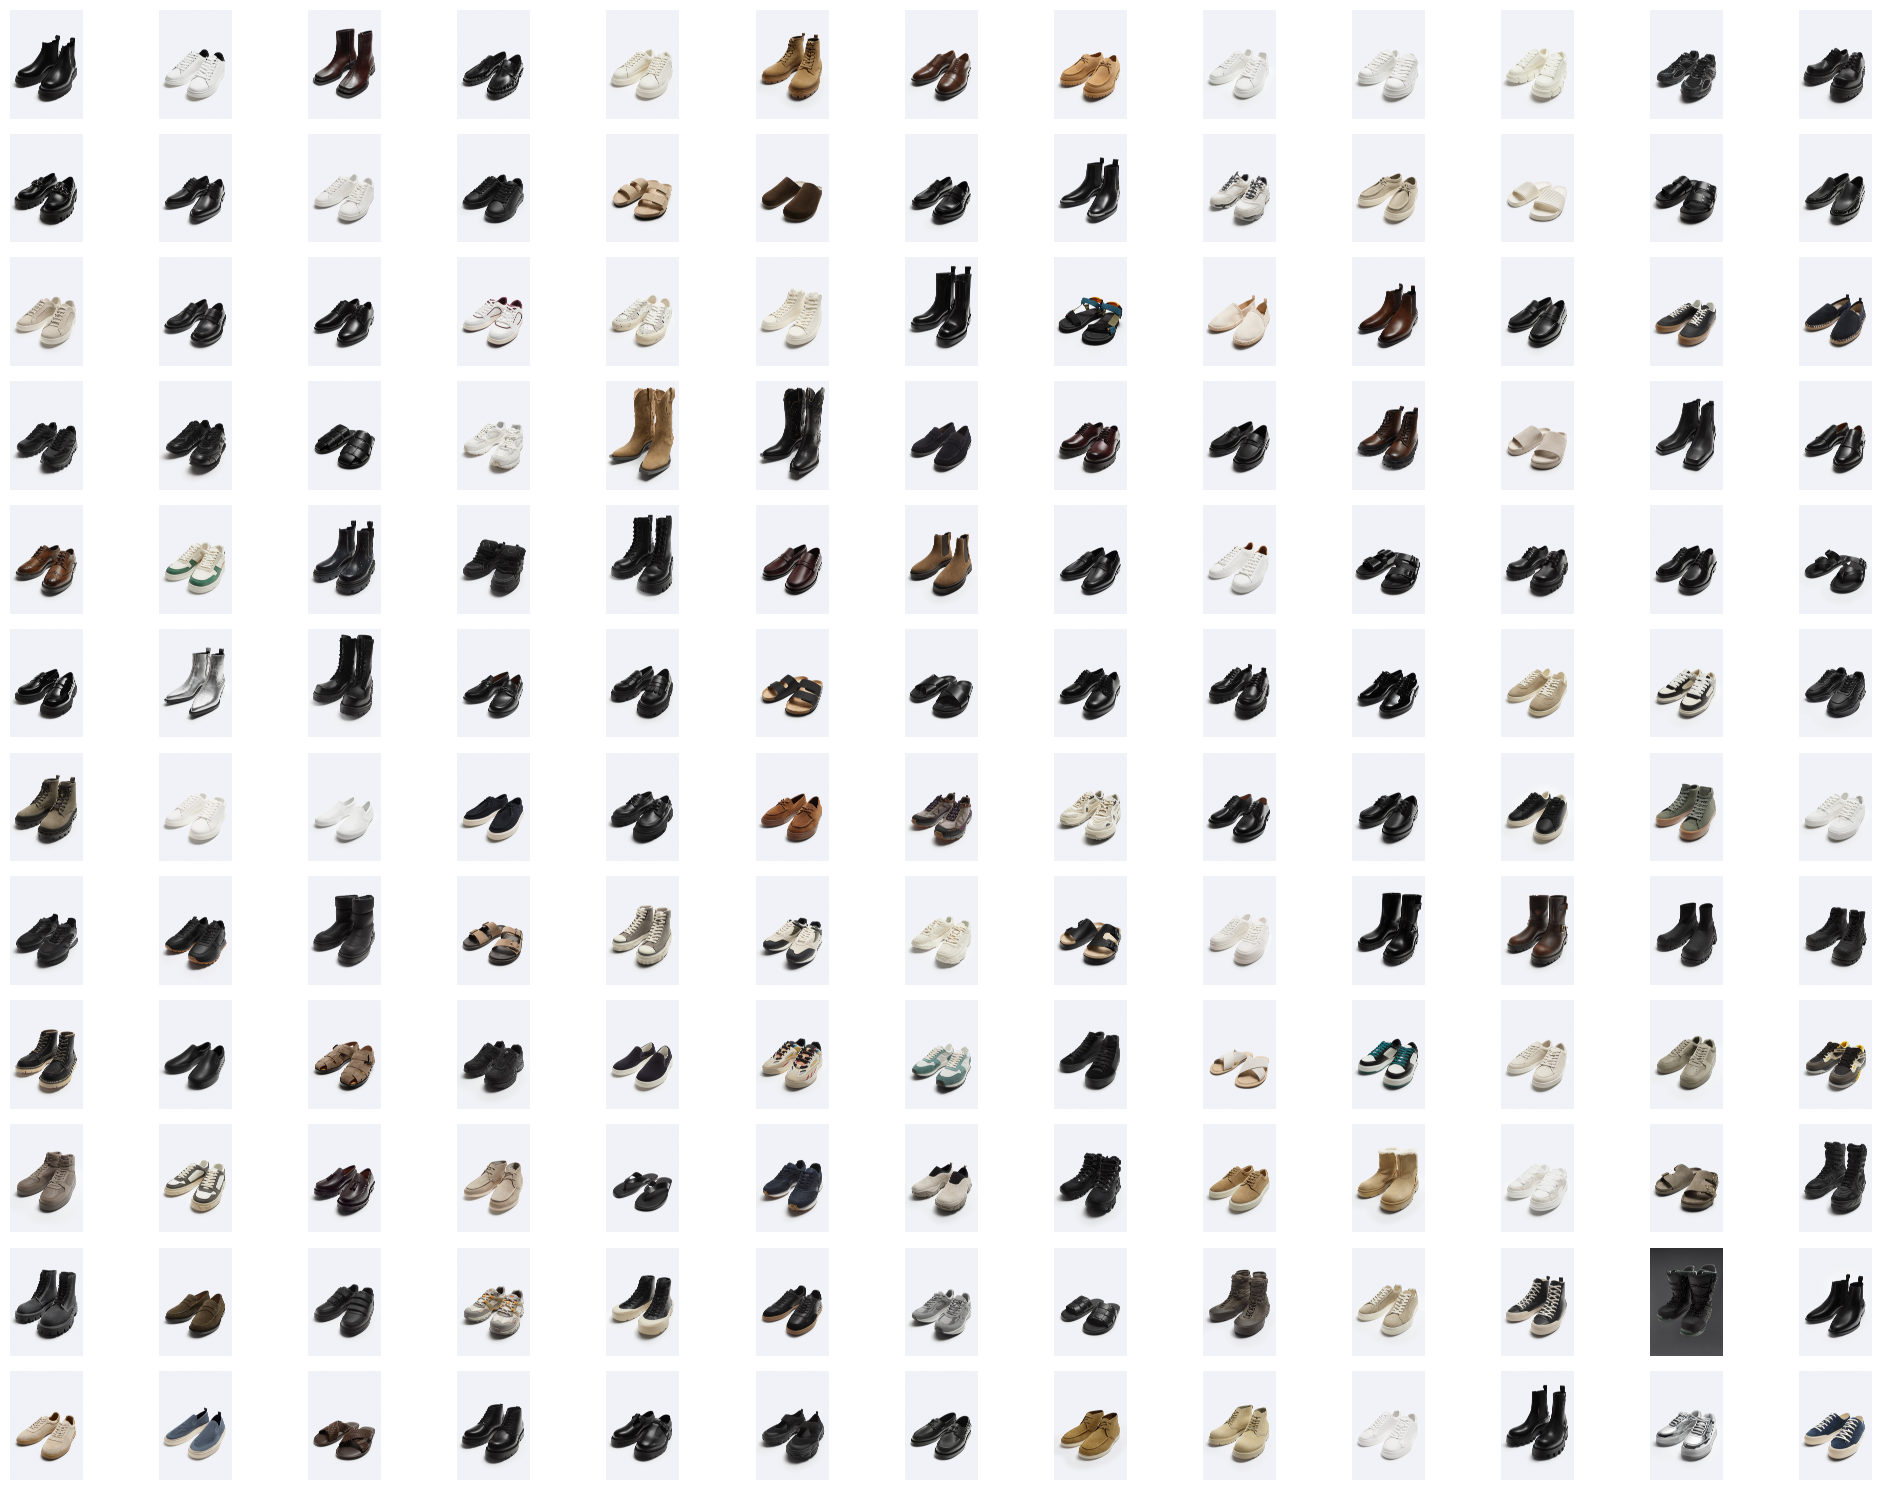

In [51]:
total_iso_images =df_zara_man_shoes['iso_image'].to_list()
show_images12x13(total_iso_images)


In [52]:
df_zara_man_shoes

,name,description,price,currency,terms,image_downloads,edition_type,category,total_images,iso_image
0,chunky sole chelsea boots,Chelsea boots. Shaft with elastic goring on bo...,59.90,USD,shoes,"[8569e73f-b1be-476a-89b4-9afa3f6ff89b, d54a73b...",,boots,6,30d15b5c-bb33-4804-9c90-59b884a9be63
1,chunky sole sneakers,Sneakers. Upper in a combination of materials ...,49.90,USD,shoes,"[38da5001-d5b0-462c-8372-f5381e17ea17, af82553...",,sneakers,6,a6e76df6-a31d-46f4-b44f-9c0118bf098b
2,squared toe leather boots,Leather ankle boots. Square shaped. Side zippe...,159.00,USD,shoes,"[999f3076-ca9c-4ca5-b23f-f6182ae29ca6, 435cc09...",,boots,4,435cc093-08b5-48e0-91ba-cfce112d4105
3,polished leather penny loafers,Loafers. Made of leather. Smooth exterior. Orn...,119.00,USD,shoes,"[9fb8d07e-6e1a-4553-87ef-cb9395d3818c, a0de30c...",,loafers,6,e1e53a03-4ecc-4925-9425-9fb8a614a097
4,monochrome chunky sole sneakers,Sneakers with tonal pieces at upper. Lacing wi...,59.90,USD,shoes,"[5081d81b-1381-417d-8ce8-11608706e4c2, 42443a6...",,sneakers,7,083247f1-2158-46bc-a926-cacfd9a5537c
...,...,...,...,...,...,...,...,...,...,...
153,rubberized heel sneakers,Monochromatic sneakers. Upper in a combination...,9.99,USD,shoes,"[8bc7dfd2-19f8-41eb-a8b6-ce44fdfdad26, 6182290...",,sneakers,4,6182290e-0ece-45ed-b3cb-6741a87e42b2
154,chunky sole zipper boots,Monochromatic ankle boots with side zipper. Ba...,89.90,USD,shoes,"[b68cfee3-39fd-4990-b500-b4beae090dcb, 3c2ef2a...",,boots,4,3c2ef2af-6b90-45d5-b98d-263b3633952e
155,metallic retro sneakers,Sneakers. Upper in a combination of pieces and...,59.90,USD,shoes,"[6973963e-3c85-4523-b0d4-0f21046cc0be, 68413cc...",,sneakers,6,31330cb5-d1a8-4d2f-909c-19f73c92b883
156,leather sneakers,Sneakers. Made of leather with a suede finish....,89.90,USD,shoes,"[4a9ccdac-9455-426c-958a-f6a99e21c42a, a9b0392...",,sneakers,4,a9b03925-cdea-4c79-be80-4e91294e8932
